In [14]:
import pandas as pd

test_data = pd.read_csv("../data/test.csv")
features = pd.read_csv("../data/features.csv")
stores = pd.read_csv("../data/stores.csv")

test_data = test_data.merge(features,on =["Store", "Date", "IsHoliday"],how="left")
test_data =test_data.merge(stores,on = ["Store"], how = "left")

test_data.head()

test_data.head()

,Store,Dept,Date,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2012-11-02,False,55.32,3.386,6766.44,5147.70,50.82,3639.90,2737.42,223.462779,6.573,A,151315
1,1,1,2012-11-09,False,61.24,3.314,11421.32,3370.89,40.28,4646.79,6154.16,223.481307,6.573,A,151315
2,1,1,2012-11-16,False,52.92,3.252,9696.28,292.10,103.78,1133.15,6612.69,223.512911,6.573,A,151315
3,1,1,2012-11-23,True,56.23,3.211,883.59,4.17,74910.32,209.91,303.32,223.561947,6.573,A,151315
4,1,1,2012-11-30,False,52.34,3.207,2460.03,NaN,3838.35,150.57,6966.34,223.610984,6.573,A,151315


In [15]:
test_data["Date"] = pd.to_datetime(test_data["Date"])
test_data["year"] = test_data["Date"].dt.year
test_data["month"] = test_data["Date"].dt.month
test_data["day"] = test_data["Date"].dt.day

test_data.drop("Date", axis=1, inplace=True)
test_data = pd.get_dummies(test_data ,columns=["Store" , "IsHoliday" , "Type"], drop_first=True)
test_data.head()

,Dept,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,...,Store_39,Store_40,Store_41,Store_42,Store_43,Store_44,Store_45,IsHoliday_True,Type_B,Type_C
0,1,55.32,3.386,6766.44,5147.70,50.82,3639.90,2737.42,223.462779,6.573,...,False,False,False,False,False,False,False,False,False,False
1,1,61.24,3.314,11421.32,3370.89,40.28,4646.79,6154.16,223.481307,6.573,...,False,False,False,False,False,False,False,False,False,False
2,1,52.92,3.252,9696.28,292.10,103.78,1133.15,6612.69,223.512911,6.573,...,False,False,False,False,False,False,False,False,False,False
3,1,56.23,3.211,883.59,4.17,74910.32,209.91,303.32,223.561947,6.573,...,False,False,False,False,False,False,False,True,False,False
4,1,52.34,3.207,2460.03,NaN,3838.35,150.57,6966.34,223.610984,6.573,...,False,False,False,False,False,False,False,False,False,False


In [16]:
import joblib

best_xgb = joblib.load("../models/best_xgboost.pkl")
test_data = test_data.reindex(
    columns=best_xgb.feature_names_in_,
    fill_value=0)

print(test_data.shape)

(115064, 61)


In [17]:
prediction = best_xgb.predict(test_data)

print(len(prediction))
result = pd.read_csv("../data/test.csv")

result["predicted_weekly_sales"] = prediction

result.to_csv("../data/xgboost_test_predictions.csv" , index = False)

result.head()


115064


,Store,Dept,Date,IsHoliday,predicted_weekly_sales
0,1,1,2012-11-02,False,17277.412109
1,1,1,2012-11-09,False,18247.255859
2,1,1,2012-11-16,False,16974.310547
3,1,1,2012-11-23,True,19389.228516
4,1,1,2012-11-30,False,18893.042969


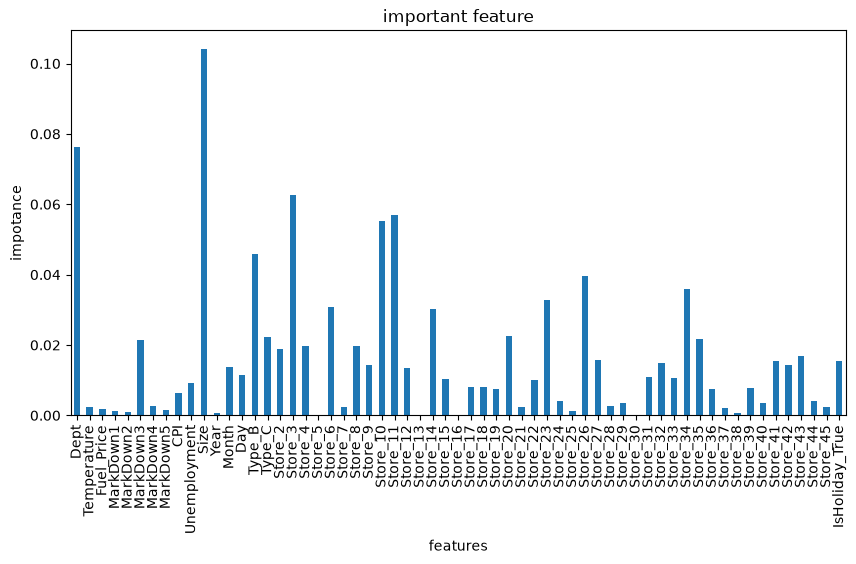

In [19]:
import matplotlib.pyplot as plt

importance = pd.Series(best_xgb.feature_importances_ , index=best_xgb.feature_names_in_)

importance.sort_values(ascending = False)
importance.plot(kind = "bar" ,figsize = (10,5))

plt.title("important feature")
plt.xlabel("features")
plt.ylabel("impotance")
plt.show()


